# Part A Single-Image Explainer

This notebook is meant for presentation use. It explains, on one sample image, what was done in **ShanghaiTech Part A**:

1. how the image is loaded  
2. how the actual count is obtained from the density map  
3. how preprocessing is done  
4. how the `CountNet` model is structured  
5. why three models were created for Part A  
6. how final prediction logic uses these model outputs

You can change the sample image in the next code cell if needed.


In [1]:
from pathlib import Path
import math
import cv2
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn

ROOT = Path.cwd()
if not (ROOT / "DATASET").exists() and (ROOT.parent / "DATASET").exists():
    ROOT = ROOT.parent

DATASET = ROOT / "DATASET"
MAPS = ROOT / "processed_density_maps"
if not MAPS.exists() and (ROOT / "ground_truth").exists():
    MAPS = ROOT / "ground_truth"

SAMPLE_ID = "IMG_116"   # change this if you want another Part A image
IMAGE_PATH = DATASET / "part_A" / "test_data" / "images" / f"{SAMPLE_ID}.jpg"
DENSITY_PATH = MAPS / "part_A" / "test" / f"{SAMPLE_ID}.h5"

print("Project root:", ROOT)
print("Image path:", IMAGE_PATH)
print("Density path:", DENSITY_PATH)
print("Image exists:", IMAGE_PATH.exists())
print("Density exists:", DENSITY_PATH.exists())


Project root: c:\Users\pendy\Desktop\s6\projects\dip
Image path: c:\Users\pendy\Desktop\s6\projects\dip\DATASET\part_A\test_data\images\IMG_116.jpg
Density path: c:\Users\pendy\Desktop\s6\projects\dip\processed_density_maps\part_A\test\IMG_116.h5
Image exists: True
Density exists: True


## Step 1: Load the sample image and density map

In this project, the ground-truth count is not typed manually. It is obtained from the density map.

The density map contains floating-point values spread across the image.  
When we sum all values in the density map, we get the **actual number of people** in the image.


In [2]:
def load_rgb(path: Path):
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.uint8)

def load_density(path: Path):
    with h5py.File(path, "r") as h:
        return h["density"][:].astype(np.float32)

image = load_rgb(IMAGE_PATH)
density = load_density(DENSITY_PATH)
actual_count = float(density.sum())

print("Image shape:", image.shape)
print("Density shape:", density.shape)
print("Actual count from density map:", actual_count)


Image shape: (396, 594, 3)
Density shape: (396, 594)
Actual count from density map: 288.0


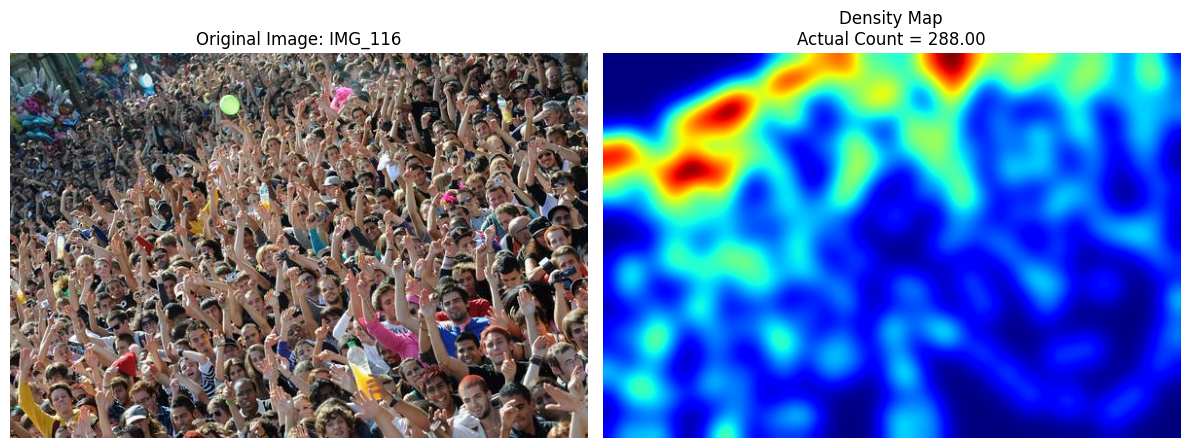

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title(f"Original Image: {SAMPLE_ID}")
axes[0].axis("off")

axes[1].imshow(density, cmap="jet")
axes[1].set_title(f"Density Map\nActual Count = {actual_count:.2f}")
axes[1].axis("off")
plt.tight_layout()


## Step 2: Preprocessing

For this project, we did not give only the raw RGB image to the model.

We created a **fused input**:

- first 3 channels: original RGB image  
- next 3 channels: CLAHE-enhanced grayscale image repeated into 3 channels

Why this was done:

- RGB keeps original scene information  
- CLAHE improves local contrast  
- crowd head patterns and dense textures often become easier to learn after local contrast enhancement


In [4]:
rgb = image.astype(np.float32) / 255.0
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
clahe_3 = np.repeat(clahe[..., None], 3, axis=2).astype(np.float32) / 255.0
fused = np.concatenate([rgb, clahe_3], axis=2)

print("RGB shape:", rgb.shape)
print("CLAHE 3-channel shape:", clahe_3.shape)
print("Fused shape:", fused.shape)


RGB shape: (396, 594, 3)
CLAHE 3-channel shape: (396, 594, 3)
Fused shape: (396, 594, 6)


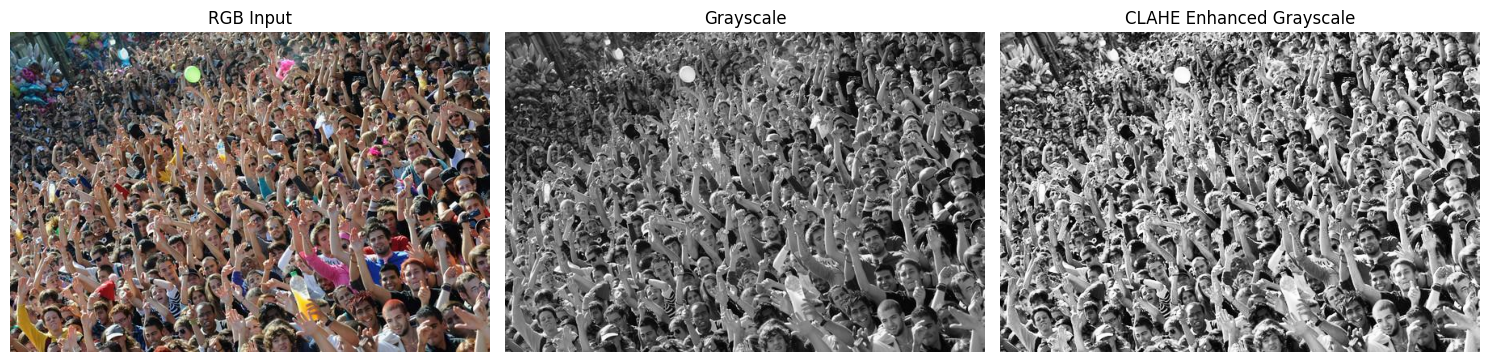

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("RGB Input")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(clahe, cmap="gray")
axes[2].set_title("CLAHE Enhanced Grayscale")
axes[2].axis("off")
plt.tight_layout()


## Step 3: Why Part A uses three models

ShanghaiTech Part A is difficult because crowd counts vary a lot.

So instead of trusting one model for every case, three specialized models were created:

- **Sparse model** for lower crowd counts  
- **Low model** for the main middle range  
- **Dense model** for very crowded scenes

These three models use the same core `CountNet` architecture, but they are trained on different crowd-density ranges.


In [6]:
PART_A_BOUNDS = (150.0, 520.0)
DENSE_CUT = 620.0

def crowd_bucket(count, bounds=PART_A_BOUNDS):
    if count < bounds[0]:
        return "low-count bucket"
    if count < bounds[1]:
        return "mid-count bucket"
    return "high-count bucket"

def regime_label(count):
    if count <= 220:
        return "sparse regime"
    if count >= DENSE_CUT:
        return "dense regime"
    return "low/main regime"

print("Sample bucket:", crowd_bucket(actual_count))
print("Sample regime:", regime_label(actual_count))


Sample bucket: mid-count bucket
Sample regime: low/main regime


## Step 4: `CountNet` architecture

`CountNet` is the main Part A model architecture used in this project.

It contains:

- residual blocks for feature extraction  
- squeeze-excitation attention for channel importance  
- a density-map branch  
- a count regression branch  
- a bucket classification branch

This makes the model better suited for crowd counting than a plain single-output CNN, because it learns:

- where the crowd is  
- how dense it is  
- and what the total count should be


In [7]:
class SE(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(True),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.block(x)


class RB(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.proj = (
            nn.Identity()
            if in_ch == out_ch and stride == 1
            else nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, 0),
                nn.BatchNorm2d(out_ch),
            )
        )
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.BatchNorm2d(out_ch),
            SE(out_ch),
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        return self.relu(self.proj(x) + self.block(x))


class CountNet(nn.Module):
    def __init__(self, input_channels=6):
        super().__init__()
        self.encoder = nn.Sequential(
            RB(input_channels, 32, 2),
            RB(32, 64, 2),
            RB(64, 96, 1),
            RB(96, 128, 2),
            RB(128, 160, 1),
            RB(160, 192, 1),
        )
        self.density_head = nn.Sequential(
            nn.Conv2d(192, 128, 3, 1, 1),
            nn.ReLU(True),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 1, 1),
            nn.Softplus(),
        )
        self.pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.count_head = nn.Sequential(
            nn.Linear(192, 128),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )
        self.bucket_head = nn.Sequential(
            nn.Linear(192, 64),
            nn.ReLU(True),
            nn.Dropout(0.1),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        features = self.encoder(x)
        density = self.density_head(features)
        pooled = self.pool(features)
        count = self.count_head(pooled)
        bucket = self.bucket_head(pooled)
        return density, count, bucket


model = CountNet(input_channels=6)
model


CountNet(
  (encoder): Sequential(
    (0): RB(
      (proj): Sequential(
        (0): Conv2d(6, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (block): Sequential(
        (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): SE(
          (block): Sequential(
            (0): AdaptiveAvgPool2d(output_size=1)
            (1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (2): ReLU(inplace=True)
            (3): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (4): Sigmoid()
          )
        )
      )
      (relu): ReLU(inplace=True)
    )

In [8]:
param_count = sum(p.numel() for p in model.parameters())
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", f"{param_count:,}")
print("Trainable parameters:", f"{trainable_count:,}")


Total parameters: 1,920,285
Trainable parameters: 1,920,285


## Step 5: How different Part A models were created

The architecture remains the same, but different model instances were trained:

- `sparse_model = CountNet(...)`
- `low_model = CountNet(...)`
- `dense_model = CountNet(...)`

What makes them different is **how they were trained**:

- sparse model saw lower-count images  
- low model saw the main working range  
- dense model saw very crowded images

So they are not different because of different layers.  
They are different because they learned from different count regimes.


In [9]:
sparse_model = CountNet(input_channels=6)
low_model = CountNet(input_channels=6)
dense_model = CountNet(input_channels=6)

print("Three separate model instances created:")
print("1. sparse_model")
print("2. low_model")
print("3. dense_model")


Three separate model instances created:
1. sparse_model
2. low_model
3. dense_model


## Step 6: What final guarded prediction means

In Part A, the final prediction is not simply taken from one model.

Instead:

1. sparse model gives one prediction  
2. low model gives one prediction  
3. dense model gives one prediction  
4. guarded logic decides how much dense output should be trusted

This was done because the dense model can help in very crowded scenes, but it can also overestimate moderate scenes if used carelessly.


In [10]:
part_a_csv = ROOT / "DATASET" / "prediction_results_part_a.csv"
if part_a_csv.exists():
    row = pd.read_csv(part_a_csv)
    row = row[row["image_id"] == SAMPLE_ID]
    display(row)
else:
    print("prediction_results_part_a.csv not found yet.")


,part,split,image_id,image_path,actual_count,density_count_pred,aux_density_count_pred,strategy_name,blend_alpha,raw_predicted_count,predicted_count,signed_error,absolute_error
19,A,test,IMG_116,DATASET/part_A/test_data/images/IMG_116.jpg,288.0,154.701279,1013.102661,guarded_main_fused,0.0,297.980103,317.778113,29.778113,29.778113


## Final explanation for presentation

For Part A, the project uses a **fused input** and a **three-model CountNet system**.

- Fused input means RGB + CLAHE-enhanced grayscale  
- CountNet learns density, count, and bucket information  
- Three separate models were trained for sparse, low, and dense crowd regimes  
- Final prediction is generated using guarded fusion logic rather than trusting one branch blindly

This is why Part A is more complex than Part B.
